# R09-H63 - dark matter: the census of the unreachable

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-06 <br>
**Pipeline stage**: R09 graph topology round, hygiene family <br>
**Graph**: rebuilt CPAP graph (neo4j2), 28-probe gold set <br>

Measures how much of the graph is reachable at all under production seeding. For every probe:
seeds (vector + proposition channels) plus their 2-hop neighborhood; the union across the probe
set is the graph's lit region, everything else is dark matter. The registered claims: >=30% of
entities are dark, >=70% of dark matter qualifies for the H60 low-evidence prune set, and zero
gold-carrying entities are dark (if gold IS dark, this flips from a hygiene fact to a seeding alarm).

Scope note: registered against the campaign graph; the probe set with gold evidence exists on the
CPAP graph, so the census runs here - the campaign version lands with the wave-end probe cycle.

## Approach
1. **Lit region** - per probe: production seeds (vec-8 + prop) and wide seeds (vec-16 + prop);
   2-hop BFS; union across probes
2. **Prune qualification** - H60 criteria per entity: single-chunk provenance, no prop_* keys,
   no attached propositions
3. **Verdict** - dark share >= 0.30, prune overlap >= 0.70, dark golds == 0

## Outputs
- `reports/dark-matter-r09h63-<stamp>.json` - shares, overlaps, dark-gold list
- In-notebook: reachability breakdown, verdict

In [1]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report persistence
import os  # graph selection env
import re  # evidence normalization
from collections import deque  # BFS

# third party
import yaml  # probe set
import matplotlib.pyplot as plt  # breakdown figure
from pathlib import Path
from rich import print as rprint  # semantic output
from rich.progress import Progress  # census loop

os.environ["NEO4J_URI"] = "bolt://user-konrad.jelen-kgf-neo4j2:7687"
os.environ["NEO4J_USER"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "kgfoundry"

# project
from knowledge_graph_foundry import Foundry, load_settings  # pipeline
from knowledge_graph_foundry.extraction import generate_embeddings  # Titan probe embedding
from knowledge_graph_foundry.graph.graphrag import vector_query  # seed channel
from knowledge_graph_foundry.graph.propositions import proposition_query  # seed channel
from knowledge_graph_foundry.models import Entity  # embedding probe wrapper

2026-07-06 22:04:14.031 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


In [2]:
# Configuration
PROBES_PATH = Path("../tests/probes/cpap-probe-set.yml")

settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k
TOP_K_WIDE = 16
PROP_TOP_K = settings.graphrag.proposition_top_k
VEC_INDEX = settings.graphrag.vector_index_name
PROP_INDEX = settings.graphrag.proposition_index_name
HOPS = 2  # retrieval-first radius

# pre-registered acceptance bar (experiments log, R09-H63)
BAR_DARK_SHARE = 0.30    # >=30% of entities dark
BAR_PRUNE_OVERLAP = 0.70 # >=70% of dark matter is H60-prunable
# critical refuter: any gold-carrying entity dark

probes = yaml.safe_load(PROBES_PATH.read_text())
gold_probes = [p for p in probes if p.get("gold_evidence")]

rprint(f"""[bold cyan]Configuration[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
[bold]Graph[/bold]
  Neo4j: [cyan]{os.environ['NEO4J_URI']}[/cyan]

[bold]Census[/bold]
  Seeds: vec [yellow]{TOP_K}[/yellow]/[yellow]{TOP_K_WIDE}[/yellow] + prop [yellow]{PROP_TOP_K}[/yellow]  Radius: [yellow]{HOPS}[/yellow] hops
  Probes: [yellow]{len(gold_probes)}[/yellow] with gold evidence

[bold]Acceptance bar[/bold]
  Dark share >= [yellow]{BAR_DARK_SHARE}[/yellow]  Prune overlap >= [yellow]{BAR_PRUNE_OVERLAP}[/yellow]  Dark golds == [yellow]0[/yellow]
""")

Configuration
────────────────────────────────────────
Graph
  Neo4j: bolt://user-konrad.jelen-kgf-neo4j2:7687

Census
  Seeds: vec 8/16 + prop 8  Radius: 2 hops
  Probes: 24 with gold evidence

Acceptance bar
  Dark share >= 0.3  Prune overlap >= 0.7  Dark golds == 0

## Graph, carriers and prune qualification

One bulk pass: adjacency over valid non-SIMILAR_TO edges, carrier surfaces (H67 method),
and the H60 prune predicate per entity (single-chunk provenance AND no prop_* keys AND no
attached propositions).

In [3]:
with Foundry(settings) as f:
    with f.driver.session() as s:
        ents = s.run(
            "MATCH (e:Entity) "
            "OPTIONAL MATCH (p:Proposition)-[:ABOUT]->(e) "
            "WITH e, count(p) AS n_props "
            "RETURN e.id AS id, e.name AS name, e.description AS description, "
            "properties(e) AS props, size(coalesce(e.source_chunks, [])) AS n_chunks, n_props"
        ).data()
        prop_texts = s.run(
            "MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text"
        ).data()
        edges = s.run(
            "MATCH (a:Entity)-[r]-(b:Entity) "
            "WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id "
            "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"
        ).data()

adj = {}
for e_ in edges:
    adj.setdefault(e_["a"], set()).add(e_["b"])
    adj.setdefault(e_["b"], set()).add(e_["a"])

by_ent_props = {}
for row in prop_texts:
    by_ent_props.setdefault(row["eid"], []).append(row["text"])

names = {r["id"]: r["name"] for r in ents}
prunable = set()
surface = {}
for r in ents:
    spec = {k.removeprefix("prop_"): v for k, v in r["props"].items() if k.startswith("prop_")}
    if r["n_chunks"] <= 1 and not spec and r["n_props"] == 0:
        prunable.add(r["id"])
    surface[r["id"]] = " ".join([
        r["name"] or "", r["description"] or "", json.dumps(spec, default=str),
        " ".join(by_ent_props.get(r["id"], [])),
    ])
for e_ in edges:
    surface[e_["a"]] += f" {e_['rel']} {names.get(e_['b'], '')}"
    surface[e_["b"]] += f" {e_['rel']} {names.get(e_['a'], '')}"

rprint(
    f"entities: [yellow]{len(ents)}[/yellow]  edges: [yellow]{len(edges)}[/yellow]  "
    f"H60-prunable: [yellow]{len(prunable)}[/yellow] ([dim]{len(prunable)/len(ents):.1%}[/dim])"
)

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `valid_to` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=41, offset=40>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 40, 'line': 1, 'column': 41}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "MATCH (a:Entity)-[r]-(b:Entity) WHERE r.valid_to IS NULL AND type(r) <> 'SIMILAR_TO' AND a.id < b.id RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel"


entities: 2798  edges: 3905  H60-prunable: 39 (1.4%)

In [4]:
def _norm(s):
    return re.sub(r"\s+", " ", s.casefold())


def value_tokens(text):
    return re.findall(r"[\w.\-/]*\d[\w.\-/]*", text)


_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"


def present(gold, ctx_norm):
    ng = _norm(gold)
    if ng in ctx_norm:
        return True
    squashed = re.sub(r"[\s,()]", "", ctx_norm)
    skeleton = re.sub(r"[\s,()]", "", re.sub(_UNIT, "", ng))
    if any(ch.isdigit() for ch in skeleton) and len(skeleton) >= 5 and skeleton in squashed:
        return True
    tokens = value_tokens(gold)
    if tokens:
        hit = sum(1 for t in tokens if _norm(t) in ctx_norm or re.sub(r"[\s,()]", "", _norm(t)) in squashed)
        return hit >= max(1, len(tokens) // 2 + (len(tokens) % 2))
    words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ng))
    ctx_words = set(re.findall(r"[a-z][a-z0-9\-]{2,}", ctx_norm))
    return bool(words) and len(words & ctx_words) / len(words) >= 0.6


norm_surface = {eid: _norm(t) for eid, t in surface.items()}
# per-(probe, gold) carrier sets: a gold is only AT RISK if ALL its carriers are
# dark - the fuzzy matcher makes many entities incidental carriers of value-like
# golds ("16 cm", "Medium"), so union-level darkness is meaningless
carriers = {}
for p in gold_probes:
    for g in p["gold_evidence"]:
        carriers[(p["id"], g)] = {eid for eid, t in norm_surface.items() if present(g, t)}
rprint(f"golds: [yellow]{len(carriers)}[/yellow]  "
       f"median carriers per gold: [yellow]{sorted(len(v) for v in carriers.values())[len(carriers)//2]}[/yellow]")

golds: 33  median carriers per gold: 24

## Lit region and verdict

Per-probe seeds (both budgets) + 2-hop BFS, unioned across the probe set. Dark matter =
never lit. Verdict against the three registered clauses.

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

2026-07-06 22:04:20.909 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 22:04:20.911 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-06 22:04:21.205 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 22:04:21.207 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

...

2026-07-06 22:04:26.641 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-06 22:04:26.885 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 22:04:26.888 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

2026-07-06 22:04:27.146 | INFO     | knowledge_graph_foundry.extraction.embeddings:_embed_bedrock:91 - Embeddings: 
1/1

2026-07-06 22:04:27.148 | INFO     | knowledge_graph_foundry.extraction.embeddings:generate_embeddings:199 - 
Generated embeddings for 1/1 entities via bedrock (0 cache hits)

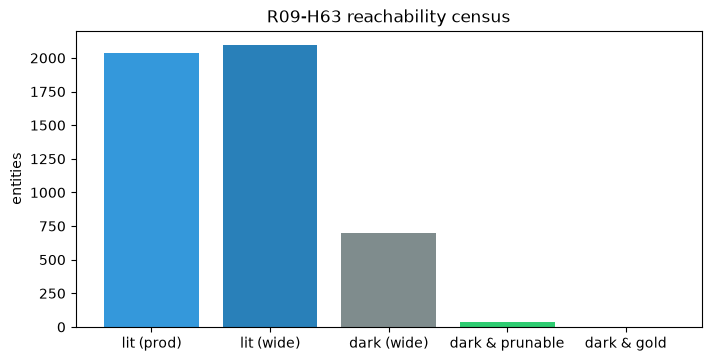

Dark-matter census
────────────────────────────────────────
  Lit (production seeds): 2036 of 2798 (72.8%)
  Lit (wide k=16): 2098 (75.0%)
  Dark share (wide): 0.250 (bar >= 0.3) -> False
  Dark-prunable overlap: 0.051 (bar >= 0.7) -> False
  Dark gold carriers: 0 (bar == 0) -> True
  Verdict: PARTIAL

saved ../reports/dark-matter-r09h63-20260706-200427.json

In [5]:
def bfs_region(sources, adj, max_hops):
    dist = {s_: 0 for s_ in sources}
    q = deque(sources)
    while q:
        u = q.popleft()
        if dist[u] >= max_hops:
            continue
        for v in adj.get(u, ()):
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return set(dist)


lit_prod, lit_wide = set(), set()
with Foundry(settings) as f, Progress() as progress:
    task = progress.add_task("lit-region census", total=len(gold_probes))
    for p in gold_probes:
        q_ = p["question"]
        probe_e = Entity.create(q_[:80], types=["Query"], description=q_)
        emb = generate_embeddings([probe_e], settings.embeddings)[0].embedding
        vec16 = [s_["id"] for s_ in vector_query(f.driver, emb, VEC_INDEX, top_k=TOP_K_WIDE)]
        prop_hits = proposition_query(f.driver, emb, PROP_INDEX, top_k=PROP_TOP_K)
        prop_ids = [eid for h in prop_hits for eid in h["entity_ids"]]
        lit_prod |= bfs_region(set(vec16[:TOP_K]) | set(prop_ids), adj, HOPS)
        lit_wide |= bfs_region(set(vec16) | set(prop_ids), adj, HOPS)
        progress.advance(task)

all_ids = set(surface)
dark_prod = all_ids - lit_prod
dark_wide = all_ids - lit_wide
dark_share = len(dark_wide) / len(all_ids)
overlap = len(dark_wide & prunable) / max(len(dark_wide), 1)
# a gold is dark only if EVERY carrier is dark (no lit entity can surface it)
dark_golds = sorted(
    f"{pid}: {g[:60]}" for (pid, g), cs in carriers.items()
    if cs and cs <= dark_wide
)

clause1 = dark_share >= BAR_DARK_SHARE
clause2 = overlap >= BAR_PRUNE_OVERLAP
clause3 = len(dark_golds) == 0
verdict = "CONFIRMED" if clause1 and clause2 and clause3 else (
    "SEEDING ALARM" if not clause3 else "PARTIAL")

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
cats = ["lit (prod)", "lit (wide)", "dark (wide)", "dark & prunable", "dark & gold"]
vals = [len(lit_prod), len(lit_wide), len(dark_wide), len(dark_wide & prunable), len(dark_golds)]
ax.bar(cats, vals, color=["#3498DB", "#2980B9", "#7F8C8D", "#2ECC71", "#E74C3C"])
ax.set(ylabel="entities", title="R09-H63 reachability census")
plt.show()

rprint(f"""[bold cyan]Dark-matter census[/bold cyan]
[dim]{"\u2500" * 40}[/dim]
  Lit (production seeds): [yellow]{len(lit_prod)}[/yellow] of {len(all_ids)} ([dim]{len(lit_prod)/len(all_ids):.1%}[/dim])
  Lit (wide k=16): [yellow]{len(lit_wide)}[/yellow] ([dim]{len(lit_wide)/len(all_ids):.1%}[/dim])
  Dark share (wide): [yellow]{dark_share:.3f}[/yellow] [dim](bar >= {BAR_DARK_SHARE})[/dim] -> [{'green' if clause1 else 'red'}]{clause1}[/]
  Dark-prunable overlap: [yellow]{overlap:.3f}[/yellow] [dim](bar >= {BAR_PRUNE_OVERLAP})[/dim] -> [{'green' if clause2 else 'red'}]{clause2}[/]
  Dark gold carriers: [yellow]{len(dark_golds)}[/yellow] [dim](bar == 0)[/dim] -> [{'green' if clause3 else 'red'}]{clause3}[/]
  Verdict: [{'green' if verdict == 'CONFIRMED' else 'red'}]{verdict}[/]
""")
for dg in dark_golds[:10]:
    rprint(f"  [red]fully dark gold:[/red] {dg}")

stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"dark-matter-r09h63-{stamp}.json"
out.write_text(json.dumps({
    "entities": len(all_ids), "lit_prod": len(lit_prod), "lit_wide": len(lit_wide),
    "dark_share_wide": dark_share, "prunable": len(prunable),
    "dark_prunable_overlap": overlap, "dark_golds": dark_golds,
    "verdict": verdict,
}, indent=2, default=str))
rprint("saved", str(out))